In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

images, labels = next(iter(train_loader))
print(images.shape, labels.shape)

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 151kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.10MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.8MB/s]

torch.Size([64, 1, 28, 28]) torch.Size([64])


**Задание 0**

In [ ]:
train_dataset.class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [ ]:
import random
clas_dict = {0: [], 1: [], 2: [], 3: [], 4: [], 5: [], 6: [], 7: [], 8: [], 9: []}
while (True):
  rand = random.randrange(0, len(train_dataset))
  image, label = train_dataset[rand]
  if len(clas_dict[label]) < 3:
      clas_dict[label].append(image)
  else:
    count = 0
    for i in range(0, 10):
        if len(clas_dict[i]) < 3:
            count += 1
    if count == 0:
      break


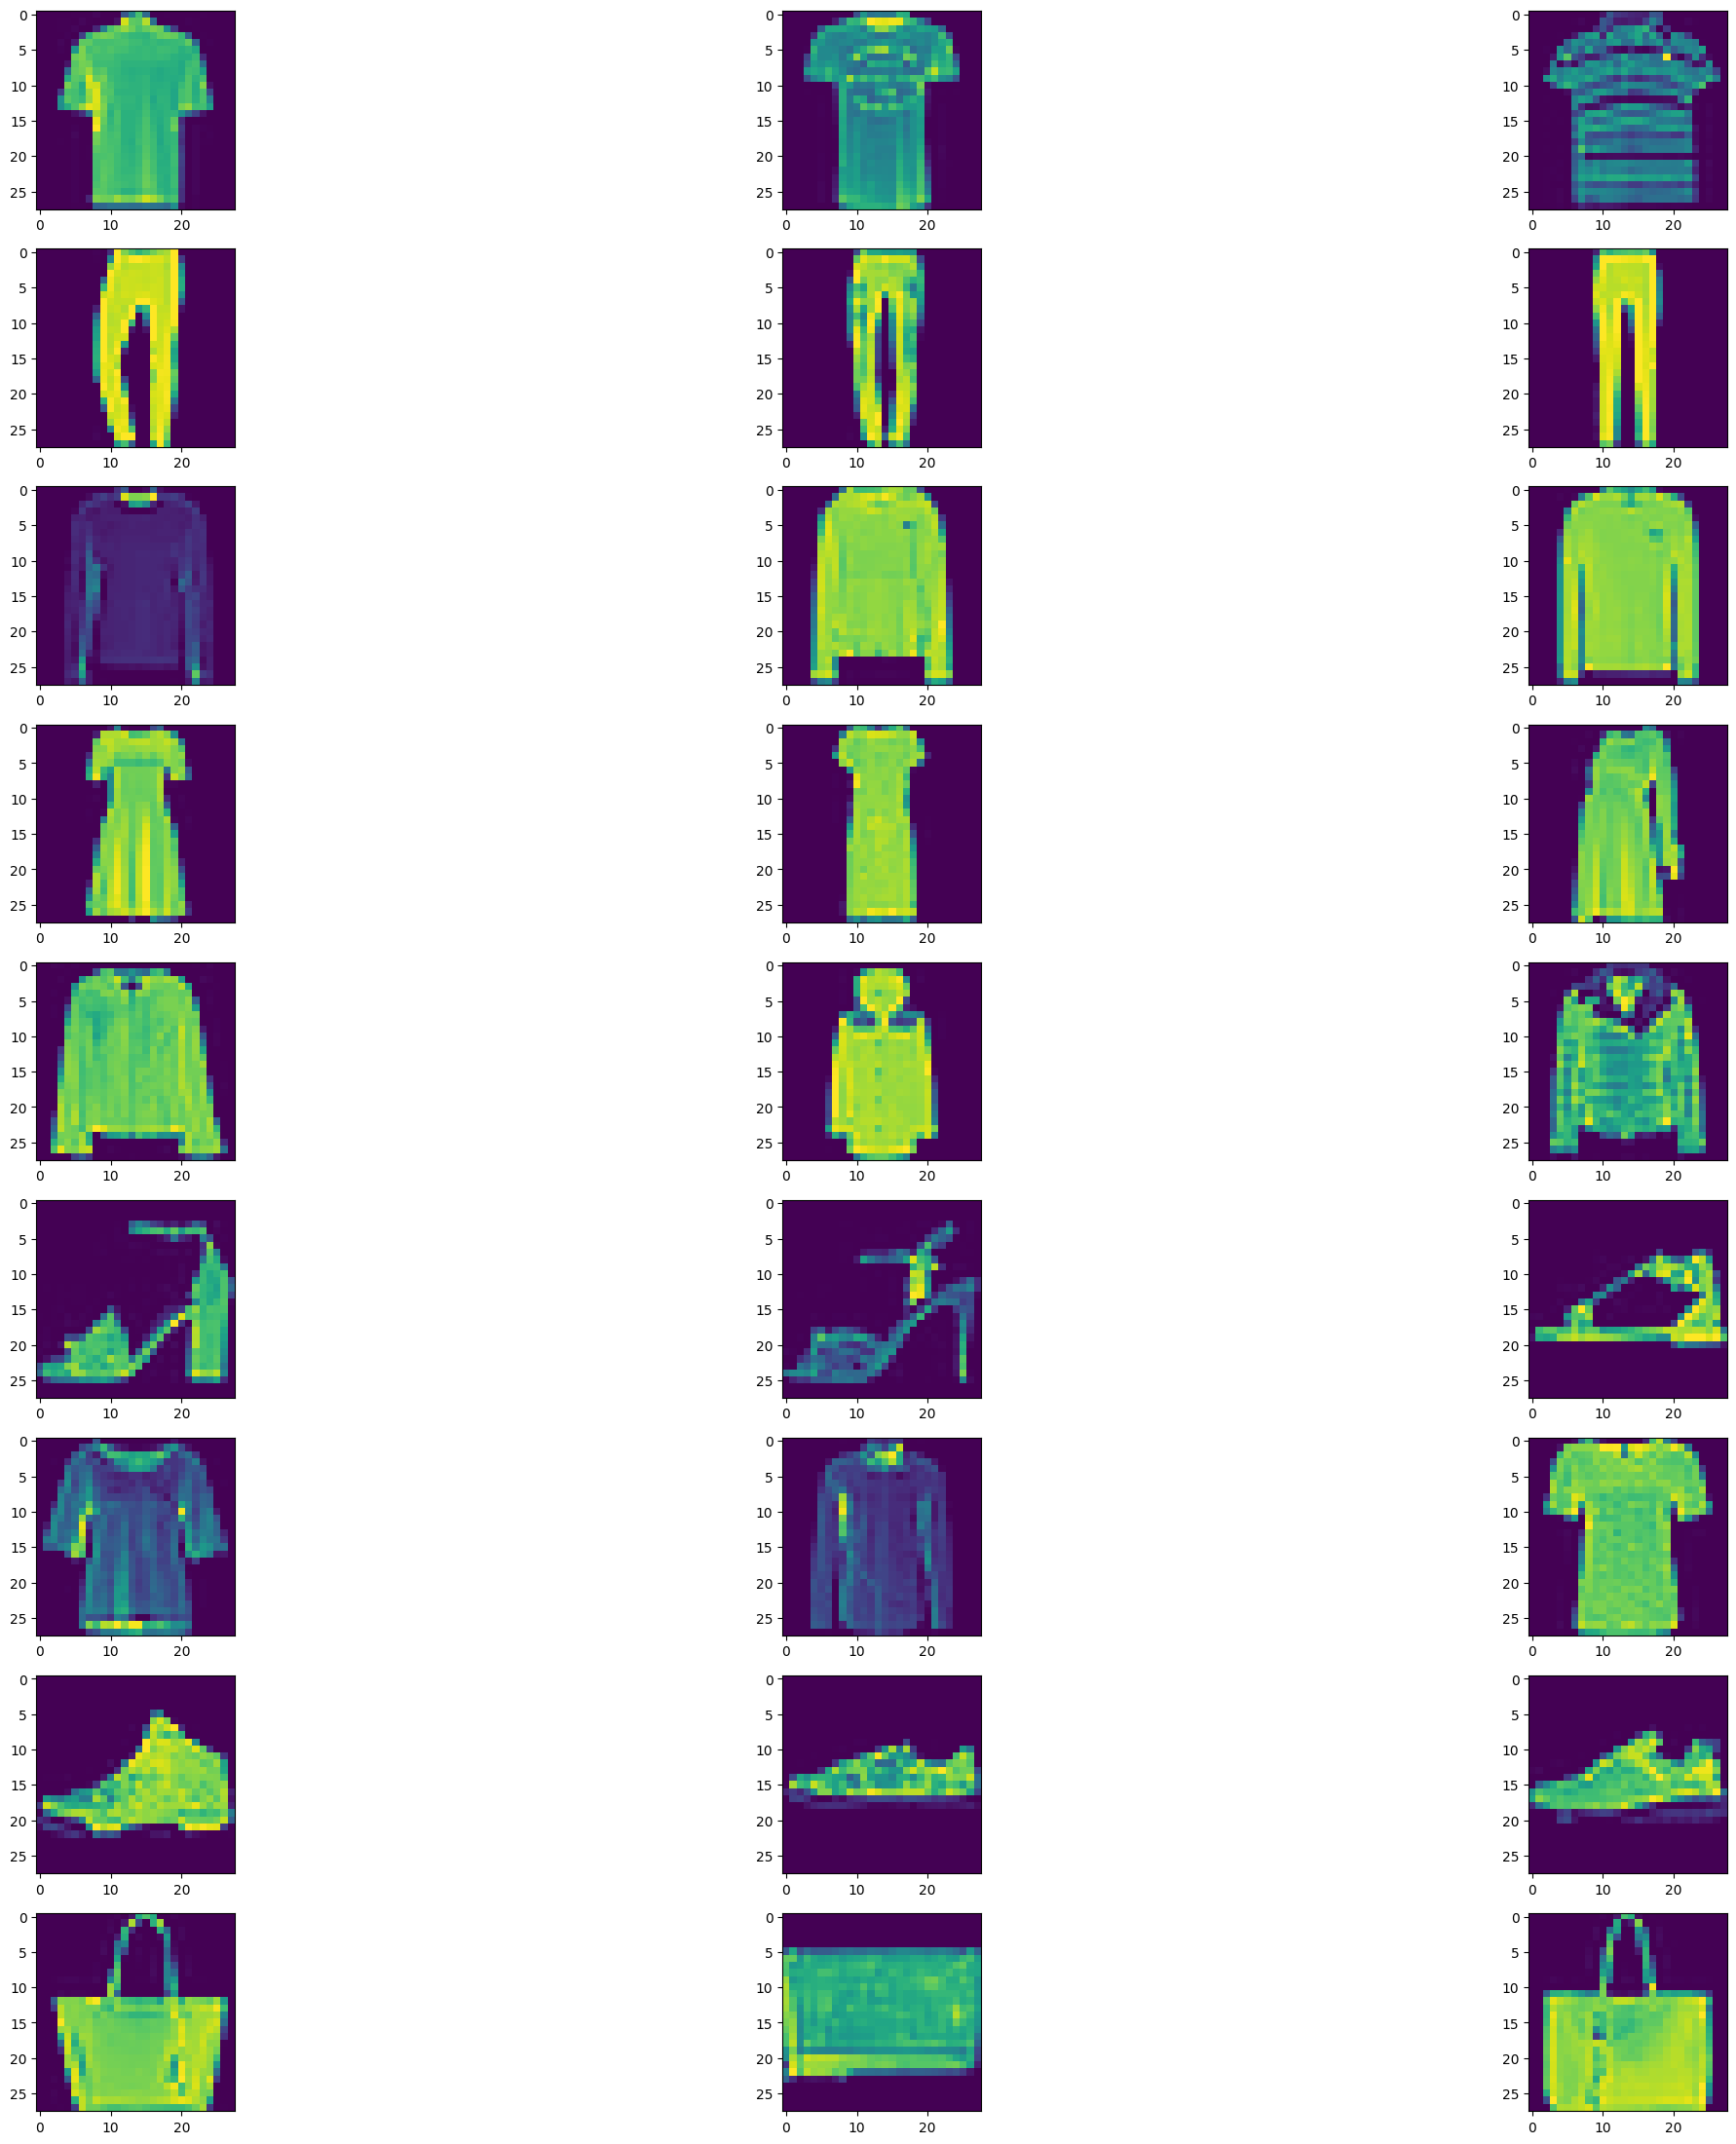

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(9, 3, figsize=(28, 28))
for i in range(9):
  for j in range(3):
    axes[i,j].imshow(clas_dict[i][j].squeeze())

Задание **1**

In [ ]:
sum_list = []
for image, label in train_dataset:
  sum_list += image.flatten().tolist()
mean = sum(sum_list) / len(sum_list)
mean

-0.42791879712701425

In [ ]:
import statistics
std = statistics.variance(sum_list) ** 0.5
std

0.7060485071303991

In [ ]:
new_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
    transforms.Normalize((mean,), (std,))
])

train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=new_transform
)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [ ]:
# Датасет только для подсчёта статистик: переводим в тензор, но НЕ нормализуем
train_dataset_for_stats = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transforms.ToTensor() # приводит к Tensor
)

stats_loader = DataLoader(train_dataset_for_stats, batch_size=512, shuffle=False)

sum_pixels = 0.0
sum_sq_pixels = 0.0
num_pixels = 0

for images, _ in stats_loader:
    # images: [B, 1, 28, 28]
    sum_pixels += images.sum().item()
    sum_sq_pixels += (images ** 2).sum().item()
    num_pixels += images.numel()

mean = sum_pixels / num_pixels
std = (sum_sq_pixels / num_pixels - mean ** 2) ** 0.5

print(f"Train mean = {mean:.6f}")
print(f"Train std  = {std:.6f}")

Train mean = 0.286041
Train std  = 0.353024


Задание 2

In [ ]:
import torch.nn as nn
class SimpleMLP(nn.Module):
  def __init__(self):
    super().__init__()
    self.net = nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 128),
        nn.ReLU(),
        nn.Linear(128, 10),
        nn.Sigmoid()
    )
  def forward(self, x):
    return self.net(x)

Задание 3

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)
model = SimpleMLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
device

device(type='cuda')

Задание 4

In [ ]:
import math
def train_and_eval(model, criterion, optimizer, device, train_loader, n_epochs=5):
  prev_loss = math.inf
  for i in range(n_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
      images = images.to(device)
      labels = labels.to(device)
      optimizer.zero_grad()
      outputs = model(images)
      loss = criterion(outputs, labels)
      loss.backward()
      optimizer.step()
      running_loss += loss.item()
    print(f"Epoch {i+1}/{n_epochs}, loss = {running_loss:.4f}")
    if running_loss >= prev_loss:
      break
    prev_loss = running_loss

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
      for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        correct += (preds==labels).sum().item()
        total += labels.size(0)
      accuracy = correct / total
      print(f"Test accuracy: {accuracy:.4f}")



In [ ]:
train_and_eval(model,criterion, optimizer, device, train_loader, 15)

Epoch 1/15, loss = 496.2554
Test accuracy: 0.7829
Epoch 2/15, loss = 424.3192
Test accuracy: 0.7397
Epoch 3/15, loss = 407.3507
Test accuracy: 0.8016
Epoch 4/15, loss = 394.5401
Test accuracy: 0.7752
Epoch 5/15, loss = 386.3477
Test accuracy: 0.7847
Epoch 6/15, loss = 386.3501


Задание 5

In [ ]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
y_test = []
y_pred = []
for images, labels in test_loader:
  images = images.to(device)
  labels = labels.to(device)
  y_test += labels.tolist()
  outputs = model(images)
  preds = outputs.argmax(dim=1)
  y_pred += preds.tolist()

print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

 T-shirt/top       0.78      0.77      0.78      1000
     Trouser       0.99      0.23      0.37      1000
    Pullover       0.44      0.81      0.57      1000
       Dress       0.47      0.87      0.61      1000
        Coat       0.79      0.17      0.27      1000
      Sandal       0.50      0.99      0.67      1000
       Shirt       0.45      0.35      0.39      1000
     Sneaker       0.89      0.63      0.74      1000
         Bag       0.95      0.80      0.87      1000
  Ankle boot       0.98      0.54      0.69      1000

    accuracy                           0.62     10000
   macro avg       0.72      0.62      0.60     10000
weighted avg       0.72      0.62      0.60     10000



In [ ]:
print(confusion_matrix(y_test, y_pred))

[[773   0   7  88   0  20 103   0   9   0]
 [  2 227  15 748   2   2   4   0   0   0]
 [ 11   0 812  13  19  12 127   0   6   0]
 [ 28   1   2 874   3  13  76   0   3   0]
 [  0   0 651  88 166   6  84   0   5   0]
 [  0   0   0   1   0 989   1   8   0   1]
 [171   1 362  56  20  25 347   0  18   0]
 [  0   0   0   0   0 364   0 628   0   8]
 [  1   1  15  10   0 131  36   5 800   1]
 [  1   0   0   1   0 397   0  65   0 536]]


In [ ]:
train_dataset.class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

Труднее всего отличать 0 и 6, 1 и 3, 2 и 6, 4 и 2, 6 и 2, 7 и 5, 9 и 5. Потому что они похожи

Задание 6

In [ ]:
from sklearn.linear_model import LogisticRegression
import numpy as np
X_train = []
y_train = []
X_test = []
y_test = []
for images, labels in train_loader:

  X_train.append(images.cpu().view(images.size(0), 784).numpy())
  y_train.append(labels.cpu().numpy())
for images, labels in test_loader:

  X_test.append(images.cpu().view(images.size(0), 784).numpy())
  y_test.append(labels.cpu().numpy())
X_train = np.concatenate(X_train, axis=0)
y_train = np.concatenate(y_train, axis=0)
X_test = np.concatenate(X_test, axis=0)
y_test = np.concatenate(y_test, axis=0)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
lr_accuracy

0.7993

In [ ]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.80      0.81      0.80      1000
           1       0.99      0.94      0.96      1000
           2       0.68      0.74      0.71      1000
           3       0.76      0.91      0.83      1000
           4       0.88      0.42      0.57      1000
           5       0.74      0.99      0.85      1000
           6       0.52      0.66      0.58      1000
           7       0.88      0.85      0.87      1000
           8       0.96      0.89      0.92      1000
           9       0.99      0.78      0.87      1000

    accuracy                           0.80     10000
   macro avg       0.82      0.80      0.80     10000
weighted avg       0.82      0.80      0.80     10000



In [ ]:
print(confusion_matrix(y_test, lr_pred))

[[809   0  11  57   1  13 100   0   9   0]
 [  7 936   4  46   1   0   6   0   0   0]
 [ 32   2 744  22  35   8 151   1   5   0]
 [ 24   3   9 910   1   2  46   0   5   0]
 [  1   1 219  81 423   4 266   0   5   0]
 [  0   0   0   0   0 989   0  10   0   1]
 [133   1  98  59  22  13 660   0  14   0]
 [  0   0   0   0   0 141   0 853   0   6]
 [  8   1   5  15   0  42  31   6 892   0]
 [  0   0   0   0   0 128   1  94   0 777]]


Задание 7

In [ ]:
import torch
import torch.nn as nn

class SimpleMLPWithDropout(nn.Module):
    def __init__(self, dropout_rate=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),

            nn.Linear(784, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
model_dropout = SimpleMLPWithDropout().to(device)

In [ ]:
import math
def train_and_eval_dropout(model, criterion, optimizer, device, train_loader, n_epochs=5):
  prev_loss = math.inf
  for i in range(n_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
      images = images.to(device)
      labels = labels.to(device)
      optimizer.zero_grad()
      outputs = model(images)
      loss = criterion(outputs, labels)
      loss.backward()
      optimizer.step()
      running_loss += loss.item()
    print(f"Epoch {i+1}/{n_epochs}, loss = {running_loss:.4f}")
    if running_loss >= prev_loss + 30:
      break
    prev_loss = running_loss

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
      for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        correct += (preds==labels).sum().item()
        total += labels.size(0)
      accuracy = correct / total
      print(f"Test accuracy: {accuracy:.4f}")



In [ ]:
train_and_eval_dropout(model_dropout,criterion, optimizer, device, train_loader, 15)

Epoch 1/15, loss = 2160.4392
Test accuracy: 0.1001
Epoch 2/15, loss = 2160.4230
Test accuracy: 0.1001
Epoch 3/15, loss = 2160.4317
Test accuracy: 0.1001
Epoch 4/15, loss = 2160.4412
Test accuracy: 0.1001
Epoch 5/15, loss = 2160.4270
Test accuracy: 0.1001
Epoch 6/15, loss = 2160.4423
Test accuracy: 0.1001
Epoch 7/15, loss = 2160.4268
Test accuracy: 0.1001
Epoch 8/15, loss = 2160.4404
Test accuracy: 0.1001
Epoch 9/15, loss = 2160.4303
Test accuracy: 0.1001
Epoch 10/15, loss = 2160.4356
Test accuracy: 0.1001
Epoch 11/15, loss = 2160.4434
Test accuracy: 0.1001
Epoch 12/15, loss = 2160.4462
Test accuracy: 0.1001
Epoch 13/15, loss = 2160.4178
Test accuracy: 0.1001
Epoch 14/15, loss = 2160.4440
Test accuracy: 0.1001
Epoch 15/15, loss = 2160.4496
Test accuracy: 0.1001
